# Denoising Autoencoder using MNIST

## Part 1: Install required libraries

In [1]:
!pip install numpy matplotlib torch torchvision scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 2: Imports and Data Loading

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

## Part 3: Noise generation function

In [3]:
def add_noise(images, noise_factor=0.4):
    noisy_images = images + noise_factor * torch.randn(*images.shape)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

## Part 4: Visualize Original vs Noisy Images

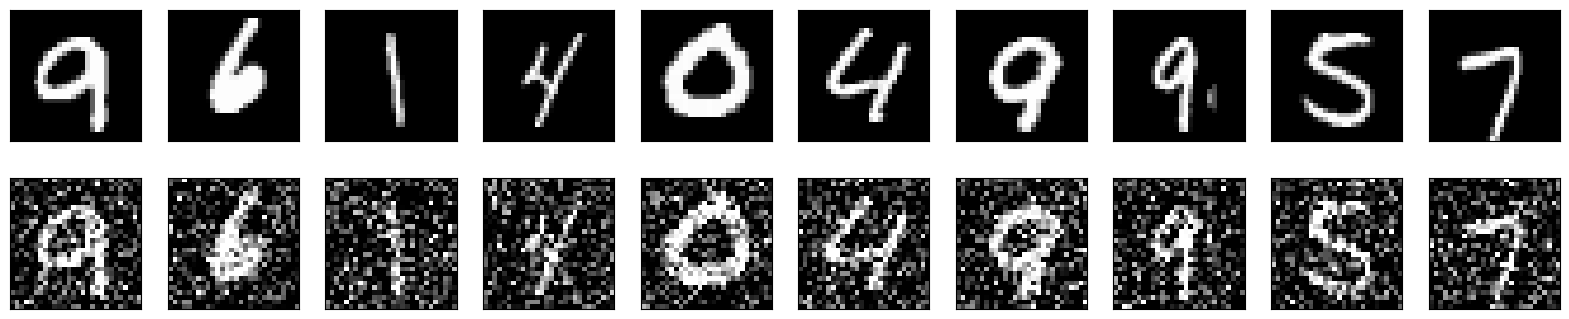

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

noisy_images = add_noise(images)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Part 5: Build the Denoising Autoencoder

In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Part 6: Train the Model

In [6]:
epochs = 5
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    for data in train_loader:
        images, _ = data
        images = images.to(device)
        
        noisy_images = add_noise(images).to(device)
        
        optimizer.zero_grad()
        
        outputs = model(noisy_images)
        loss = criterion(outputs, images)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 0.0477


Epoch [2/5], Loss: 0.0109


Epoch [3/5], Loss: 0.0102


Epoch [4/5], Loss: 0.0099


Epoch [5/5], Loss: 0.0098


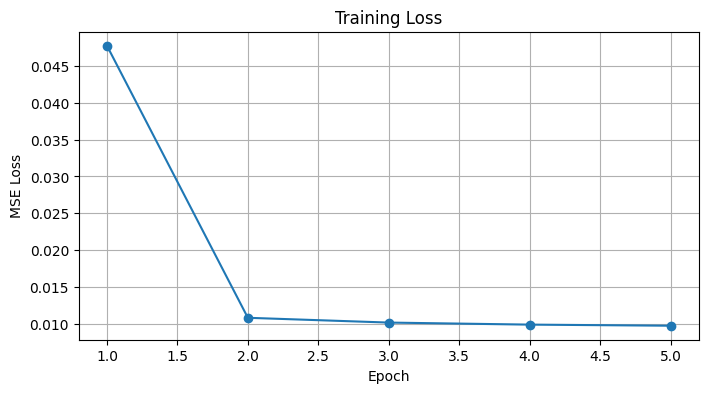

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

## Part 7: Generate denoised outputs on the test set

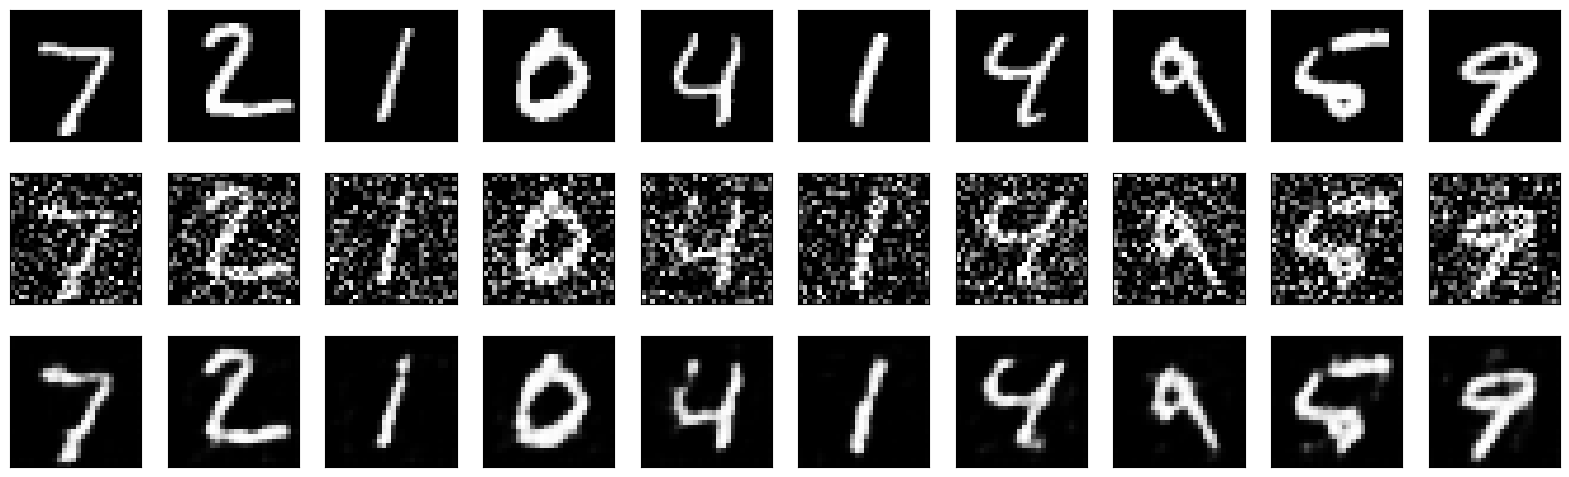

In [8]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

noisy_images = add_noise(images)

model.eval()
with torch.no_grad():
    noisy_images_device = noisy_images.to(device)
    denoised_images = model(noisy_images_device).cpu()

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Analysis and Observations

1. I loaded the MNIST data easily using PyTorch and made sure to scale the pixel values between 0 and 1 so the model can process it correctly.
2. When creating the noisy images, I realized I had to clip the values back to the [0, 1] range. Without this, the digits just looked like complete static.
3. I went with a convolutional autoencoder instead of simple dense layers because it does a much better job of keeping the shapes of the numbers intact.
4. The training went smoothly. The MSE loss dropped consistently across all 5 epochs, showing that the model was learning to map the noisy inputs back to the clean targets.
5. In the final test outputs, it's pretty cool to see how well it recovered the digits. Even when the noise was heavy, it almost perfectly reconstructed the original numbers.